In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys
sys.path.append('../')
import analysis_utils as utils

from scipy.signal import welch
from scipy.fft import rfft, irfft, rfftfreq

yale_colors = ['#00356b', '#286dc0', '#63aaff', '#4a4a4a']
utils.load_plotting_setting()

In [2]:
# For Sphere 20250103
c_mv = 8.263269630174246e-08
amp2kev = 7157.624533259538

m_sphere = 2000 * (83.5e-9**3) * (4 / 3) * np.pi  # sphere mass

In [3]:
c = 299792458    # m / s
SI2ev = (1 / 1.6e-19) * c

m = 2000 * (83.5e-9)**3 * 4 * np.pi / 3
hbar = 1.054571817e-34

In [4]:
def bad_detection_quality(zz_windowed, zz_bp_windowed):
    # Z signal out of balance, meaning that homodyne losing lock
    if np.abs(np.mean(zz_windowed)) > 0.25:
        return True
    
    if np.max(np.abs(zz_windowed)) > 0.95:
        return True

    # Check the sum over 10 indices to see if there
    # is a consecutive period of very small signal after bandpass
    convolved = np.convolve(np.abs(zz_bp_windowed),np.ones(10, dtype=int), 'valid')
    if np.sum(convolved < 1e-3) > 0:
        return True

## Make a nice figure

(-1.5, 1.5)

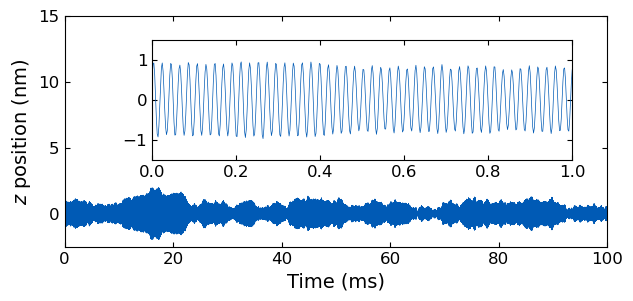

In [5]:
window_length = 5000
f = h5py.File('/Users/yuhan/work/nanospheres/data/dm_data/sphere_20250103/20250111_1e-8mbar_8e_alignment1_long/20250111_d_17.hdf5', 'r')

dtt = f['data'].attrs['delta_t']
fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V

zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

zz_shaped = np.reshape(zz, (int(zz.size / window_length), window_length))
zz_bp_shaped = np.reshape(zz_bp, (int(zz_bp.size / window_length), window_length))

f.close()

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

tt = np.arange(0, zz_bp.size) * 2e-6
ax.plot((tt-20) / 1e-3, zz_bp * c_mv/1e-9, color='#005AB5', linewidth=0.5)

ax.set_xlim(0, 100)
ax.set_ylim(-2.5, 15)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('$z$ position (nm)')

left, bottom, width, height = [0.25, 0.4, 0.6, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])

ax2.plot((tt-20) / 1e-3, zz_bp * c_mv/1e-9, color='#005AB5', linewidth=0.5)
ax2.set_xlim(0, 1)
ax2.set_ylim(-1.5, 1.5)



Text(0, 0.5, 'ASD (m/$\\sqrt{\\mathrm{Hz}}$)')

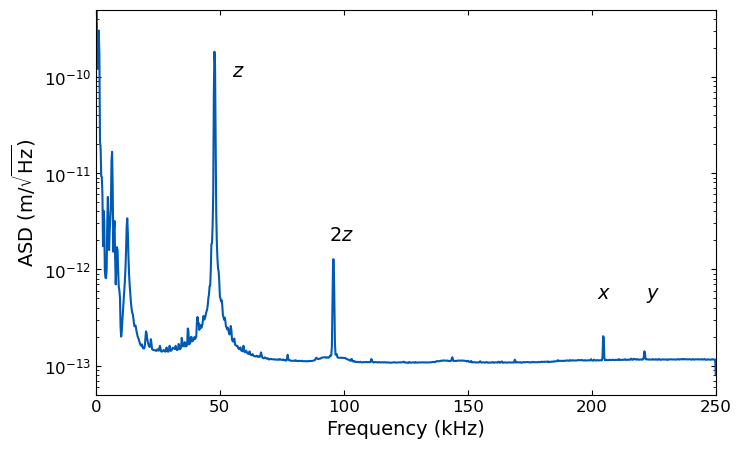

In [6]:
ff_long, pp_long = welch(zz, fs=500000, nperseg=2**11)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(ff_long/1000, np.sqrt(pp_long)*c_mv, color='#005AB5')
ax.set_yscale('log')
ax.set_xlim(0, 250)
ax.set_ylim(5e-14, 5e-10)

ax.text(55, 1e-10, r'$z$', fontsize=14)
ax.text(94, 2e-12, r'$2z$', fontsize=14)

ax.text(202, 5e-13, r'$x$', fontsize=14)
ax.text(222, 5e-13, r'$y$', fontsize=14)

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel(r'ASD (m/$\sqrt{\mathrm{Hz}}$)')


## Noise budget

In [10]:
window_length = 5000
file_idx = [56, 57, 58]

z_pp, f_pp = [], []

z_pp_welch, f_pp_welch = [], []
ff_welch = None

for idx in file_idx:
    f = h5py.File(f'/Users/yuhan/work/nanospheres/data/dm_data/sphere_20250103/20250117_8e-9mbar_0e_alignment1_long/20250117_d_{idx}.hdf5', 'r')

    dtt = f['data'].attrs['delta_t']
    fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
    zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V
    zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)
    zz_shaped = np.reshape(zz, (int(zz.size / window_length), window_length))
    zz_bp_shaped = np.reshape(zz_bp, (int(zz_bp.size / window_length), window_length))

    for i, zz in enumerate(zz_shaped):
        _, pp_welch = welch(zz, fs=500000, nperseg=2**12)
        ff_welch, pp_welch_bp = welch(zz_bp_shaped[i], fs=500000, nperseg=2**12)

        zzk = rfft(zz)
        zzk_bp = rfft(zz_bp_shaped[i])

        if bad_detection_quality(zz, zz_bp_shaped[i]):
            continue

        ff = rfftfreq(zz.size, dtt)
        pp = np.abs(zzk)**2 / (zz.size / dtt)
        pp_bp = np.abs(zzk_bp)**2 / (zz.size / dtt)

        # # if pp_bp
        if np.sum(pp_bp) > 5e-8:
            continue
        
        omega0_fit = ff[np.argmax(pp_bp)] * 2 * np.pi
        omega = ff * 2 * np.pi
        gamma = (ff[1] - ff[0]) * 2 * np.pi
        chi = 1 / (m_sphere * (omega0_fit**2 - omega**2 - 1j*gamma*omega))

        omega0_welch = ff_welch[np.argmax(pp_welch_bp)] * 2 * np.pi
        omega_welch = ff_welch * 2 * np.pi
        gamma_welch = (ff_welch[1] - ff_welch[0]) * 2 * np.pi
        chi_welch = 1 / (m_sphere * (omega0_welch**2 - omega_welch**2 - 1j*gamma_welch*omega_welch))

        z_pp_welch.append(pp_welch * c_mv**2)
        f_pp_welch.append(pp_welch * c_mv**2 / (chi_welch * np.conjugate(chi_welch)))

        z_pp.append(pp*c_mv**2)
        f_pp.append(pp*c_mv**2 / (chi * np.conjugate(chi)))

z_pp_welch = np.asarray(z_pp_welch)
f_pp_welch = np.asarray(f_pp_welch)
z_pp = np.asarray(z_pp)
f_pp = np.asarray(f_pp)

In [5]:
omega0 = 49072.265625 * 2 * np.pi
gamma_reheating = 3000 * 2 * np.pi
# gamma_reheating = 6400 * 2 * np.pi * np.sqrt(omega0 / (63100*2*np.pi))

zpf = np.sqrt(hbar / (2 * m * omega0))

S_ff_ba = hbar**2 * gamma_reheating / (zpf**2)  # N^2 / Hz
S_zz_imp = (zpf**2) / (4 * gamma_reheating)     # m^2 / Hz

# Always integrate over double-sided spectra to avoid confusion...
# also numerical integration over one-sided spectra gives incorrect values sometimes
# look into more in the future
omega_theory = np.linspace(-2*300e3*np.pi, 2*300e3*np.pi, 10000)

pi = np.pi
zpf = np.sqrt(hbar / (2 * m * omega0))  # Zero point fluctuation (m)

gamma = 122.0703125 * 2 * np.pi

# ZPF
S_zz_zpf = 0.5 * zpf**2 * gamma / ( (omega_theory-omega0)**2 + (gamma/2)**2 )

chi_ba = (1 / m) / (omega0**2 - omega_theory**2 - gamma * omega_theory * 1j) # Complex susceptibility
S_zz_tot = np.full_like(omega_theory, S_zz_imp) + S_ff_ba * np.abs(chi_ba) * np.abs(chi_ba) + S_zz_zpf

In [6]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3)(, E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
p_sca = S_ff_ba / ((A**2 + 2/5) * hbar * k / c)

print(f'Scattered laser power = {p_sca*1e6:.2f} uW')
print(f'Backaction noise] (one-sided): {S_ff_ba * 2:.3e} N^2/Hz')
print(f'Imprecision noise floor (one-sided): {S_zz_imp * 2:.3e} m^2/Hz')

Scattered laser power = 2.64 uW
Backaction noise] (one-sided): 1.196e-41 N^2/Hz
Imprecision noise floor (one-sided): 9.301e-28 m^2/Hz


In [13]:
## Estimate detection efficiency
idx = np.logical_and(ff_welch > 150000, ff_welch < 200000)

eff = S_zz_imp * 2 / np.mean((z_pp_welch.T)[idx])
eff_err = S_zz_imp * 2 / np.std((z_pp_welch.T)[idx])
print(fr'Estimated detection efficiency $\eta$: {eff:.2f} $\pm$ {eff_err/np.sqrt(z_pp_welch.shape[0]):.2f}')

Estimated detection efficiency $\eta$: 0.08 $\pm$ 0.01


In [14]:
sz_average_welch = np.mean(z_pp_welch, axis=0)
sf_average_welch = np.mean(np.real(f_pp_welch), axis=0)

chi_omega0 = 1 / (m_sphere * (- 1j * gamma_welch * omega0_welch))

sz_imp = np.mean((z_pp_welch.T)[idx])
sf_measure = np.max(sz_average_welch[ff_welch > 20000]) / (np.abs(chi_omega0)**2)

In [17]:
kb = 1.38e-23

p_mbar = 1e-8
p_pascal = p_mbar * 100

R = 8.3144  # J/(mol K)
m_gas = 2.016e-3 * 0.5 + 18.01528e-3 * 0.5  # kg / mol
T = 292  # K
vbar = np.sqrt(8 * R * T / (np.pi * m_gas))  # m/s

r_sphere_0 = 83.5e-9
m_sphere_0 = 2000 * 4/3 * np.pi * r_sphere_0**3

gamma_th = (64/3) * r_sphere_0**2 * p_pascal / (m_sphere_0 * vbar)
sf_th = 4 * kb * T * gamma_th * m_sphere_0

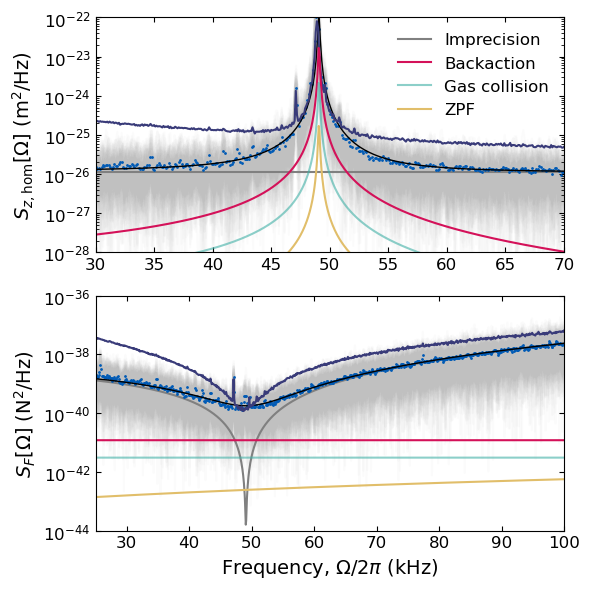

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

for i, zpp in enumerate(z_pp_welch):
    axes[0].plot(ff_welch/1000, zpp, 'silver', alpha=0.05, zorder=-5)
    axes[1].plot(ff_welch/1000, f_pp_welch[i],'silver', alpha=0.05, zorder=-5)

chi_welch = 1 / (m_sphere * (omega0_welch**2 - omega_welch**2 - 1j*gamma_welch*omega_welch))

axes[0].plot(ff_welch/1000, sz_average_welch, '.', color='#005AB5', markersize=2)
axes[0].plot(ff_welch/1000, sz_imp + sf_measure * np.abs(chi_welch)**2, color='k', linewidth=1)

axes[1].plot(ff_welch/1000, sf_average_welch, '.', color='#005AB5', markersize=2)
axes[1].plot(ff_welch/1000, sz_imp/np.abs(chi_welch)**2 + sf_measure, color='k', linewidth=1)
axes[0].plot(ff/1000, np.mean(z_pp, axis=0))
axes[1].plot(ff/1000, np.mean(f_pp, axis=0))

gamma = gamma_welch

axes[0].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp/eff), 'grey', linewidth=1.5, label='Imprecision', zorder=-5)
axes[0].plot(omega_theory/(1000*2*pi), 4 * S_ff_ba * np.abs(chi_ba)**2, color='#D41159', linewidth=1.5, label='Backaction')
axes[0].plot(omega_theory/(1000*2*pi), sf_th * np.abs(chi_ba)**2, color='#40B0A6', linewidth=1.5, alpha=0.6, label='Gas collision')
axes[0].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf, color='#E1BE6A', linewidth=1.5, label='ZPF')

axes[1].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp/eff/(np.abs(chi_ba)**2)), 'grey', linewidth=1.5, zorder=-5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, 2*S_ff_ba) , color='#D41159', linewidth=1.5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, sf_th), color='#40B0A6', linewidth=1.5, alpha=0.6)
axes[1].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf/(np.abs(chi_ba)**2), color='#E1BE6A', linewidth=1.5)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(25, 100)

axes[0].legend(frameon=False)
axes[0].set_ylabel(r'$S_{z, \mathrm{hom}}[\Omega]$ (m$^2$/Hz)')
axes[1].set_ylabel(r'$S_{F}[\Omega]$ (N$^2$/Hz)')
axes[1].set_xlabel(r'Frequency, $\Omega / 2 \pi$ (kHz)')

axes[0].set_xlim(30, 70)
axes[0].set_ylim(1e-28, 1e-22)
axes[1].set_ylim(1e-44, 1e-36)

fig.tight_layout()
fig.align_labels()


Text(0, 0.5, '$S_{z, \\mathrm{hom}}[\\Omega]$ ((m$^2$/Hz)')

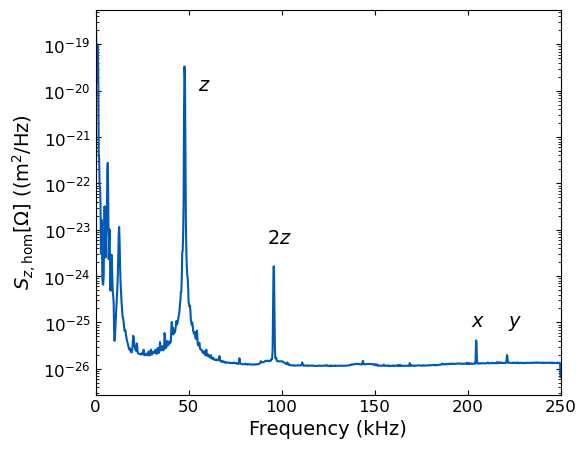

In [29]:
ff_long, pp_long = welch(zz, fs=500000, nperseg=2**11)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(ff_long/1000, pp_long*c_mv**2, color='#005AB5')
ax.set_yscale('log')
ax.set_xlim(0, 250)
# ax.set_ylim(5e-14, 5e-10)

ax.text(55, 1e-20, r'$z$', fontsize=14)
ax.text(92, 5e-24, r'$2z$', fontsize=14)

ax.text(202, 8e-26, r'$x$', fontsize=14)
ax.text(222, 8e-26, r'$y$', fontsize=14)

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel(r'$S_{z, \mathrm{hom}}[\Omega]$ ((m$^2$/Hz)')


In [39]:
omega0 = 49000 * 2 * np.pi
gamma_reheating = 3000 * 2 * np.pi
# gamma_reheating = 6400 * 2 * np.pi * np.sqrt(omega0 / (63100*2*np.pi))

zpf = np.sqrt(hbar / (2 * m * omega0))

S_ff_ba = hbar**2 * gamma_reheating / (zpf**2)  # N^2 / Hz
S_zz_imp = (zpf**2) / (4 * gamma_reheating)     # m^2 / Hz

# Always integrate over double-sided spectra to avoid confusion...
# also numerical integration over one-sided spectra gives incorrect values sometimes
# look into more in the future
omega_theory = np.linspace(-2*300e3*np.pi, 2*300e3*np.pi, 10000)

pi = np.pi
zpf = np.sqrt(hbar / (2 * m * omega0))  # Zero point fluctuation (m)

gamma = 122.0703125 * 2 * np.pi

# ZPF
S_zz_zpf = 0.5 * zpf**2 * gamma / ( (omega_theory-omega0)**2 + (gamma/2)**2 )

chi_ba = (1 / m) / (omega0**2 - omega_theory**2 - gamma * omega_theory * 1j) # Complex susceptibility
S_zz_tot = np.full_like(omega_theory, S_zz_imp) + S_ff_ba * np.abs(chi_ba) * np.abs(chi_ba) + S_zz_zpf

In [40]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3)(, E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
p_sca = S_ff_ba / ((A**2 + 2/5) * hbar * k / c)

print(f'Scattered laser power = {p_sca*1e6:.2f} uW')
print(f'Backaction noise] (one-sided): {S_ff_ba * 2:.3e} N^2/Hz')
print(f'Imprecision noise floor (one-sided): {S_zz_imp * 2:.3e} m^2/Hz')

Scattered laser power = 2.63 uW
Backaction noise] (one-sided): 1.194e-41 N^2/Hz
Imprecision noise floor (one-sided): 9.315e-28 m^2/Hz


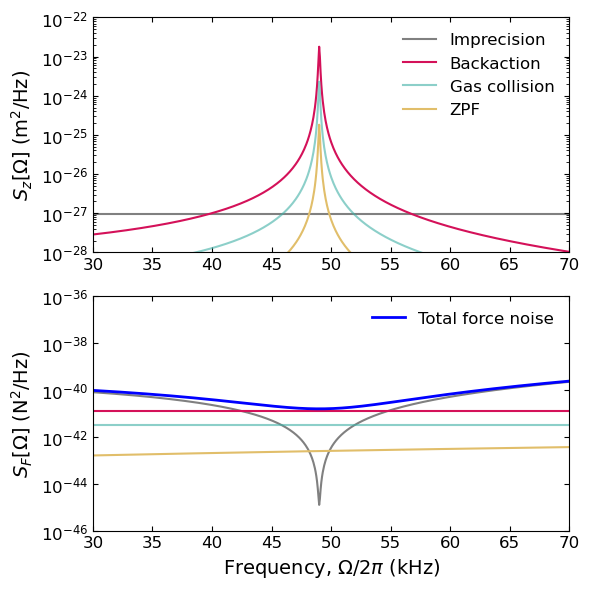

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

axes[0].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp), 'grey', linewidth=1.5, label='Imprecision', zorder=-5)
axes[0].plot(omega_theory/(1000*2*pi), 4 * S_ff_ba * np.abs(chi_ba)**2, color='#D41159', linewidth=1.5, label='Backaction')
axes[0].plot(omega_theory/(1000*2*pi), sf_th * np.abs(chi_ba)**2, color='#40B0A6', linewidth=1.5, alpha=0.6, label='Gas collision')
axes[0].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf, color='#E1BE6A', linewidth=1.5, label='ZPF')

axes[1].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp/(np.abs(chi_ba)**2)), 'grey', linewidth=1.5, zorder=-5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, 2*S_ff_ba) , color='#D41159', linewidth=1.5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, sf_th), color='#40B0A6', linewidth=1.5, alpha=0.6)
axes[1].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf/(np.abs(chi_ba)**2), color='#E1BE6A', linewidth=1.5)
sf_total = 2*S_zz_imp/(np.abs(chi_ba)**2) + 2*S_ff_ba + sf_th + 2 * S_zz_zpf/(np.abs(chi_ba)**2)

axes[1].plot(omega_theory/(1000*2*pi), sf_total, color='b', linewidth=2, label='Total force noise')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(25, 100)

axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
axes[0].set_ylabel(r'$S_{z}[\Omega]$ (m$^2$/Hz)')
axes[1].set_ylabel(r'$S_{F}[\Omega]$ (N$^2$/Hz)')
axes[1].set_xlabel(r'Frequency, $\Omega / 2 \pi$ (kHz)')

axes[0].set_xlim(30, 70)
axes[1].set_xlim(30, 70)

axes[0].set_ylim(1e-28, 1e-22)
axes[1].set_ylim(1e-46, 1e-36)

fig.tight_layout()
fig.align_labels()


In [305]:
idx_int = np.logical_and(ff_welch>20000, ff_welch<200000)
dp_kev = np.empty(f_pp_welch.shape[0])

for i, f_pp in enumerate(np.real(f_pp_welch)):
    dp_kev[i] = np.sqrt( 1/( np.trapz(1/f_pp[idx_int], x=omega_welch[idx_int]) /(2*np.pi) ) ) * SI2ev / 1000


# sf_total = sz_imp/np.abs(chi_welch)**2 + sf_measure
# delta_p_kev_theory = np.sqrt(1/(np.trapz(1/(sff_total), x=omega_theory)/(2*np.pi))) * SI2ev / 1000

# print(delta_p_kev)

In [314]:
np.sqrt(np.mean(dp_kev**2))

72.43150802414034

In [ ]:
s_f, omega0

def sz_model_log(omega, s_imp):
    chi = (1 / m_sphere) / (omega0**2 - omega**2 - 1j*gamma_welch*omega)
    return np.log(np.full_like(omega, s_imp) + np.abs(chi)**2 * s_f)

In [ ]:
omega0 = ff_welch[ff_welch>20000][np.argmax(sz_average_welch[ff_welch > 20000])] * 2 * np.pi


idx = np.logical_and(ff_welch > 150000, ff_welch < 200000)
s_zz_imp = np.mean((z_pp_welch.T)[idx])


In [91]:
from scipy.optimize import curve_fit

idx_fit = np.logical_and(ff_welch > 30000, ff_welch < 55000)
popt, pcov = curve_fit(sz_model_log, ff_welch[idx_fit]*2*np.pi, np.log(sz_average_welch[idx_fit]),
                       p0=[1e-26, 1e-40, 49000*2*np.pi],
                       bounds=([1e-27, 1e-45, 45000*2*np.pi], [1e-25, 1e-35, 51000*2*np.pi]))


In [86]:
m_sphere

4.87728384838876e-18

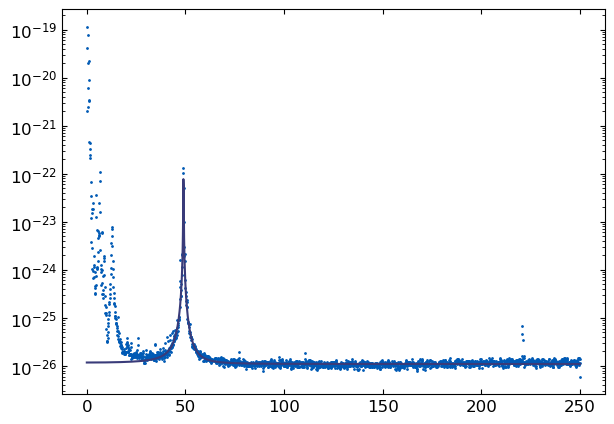

In [102]:
plt.plot(ff_welch/1000, sz_average_welch, '.', color='#005AB5', markersize=2)
# plt.plot(ff_welch/1000, np.exp(sz_model_log(ff_welch*2*np.pi, *popt)))

plt.plot(ff_welch/1000, np.exp(sz_model_log(ff_welch*2*np.pi, 1.1e-26, 1.7e-40, 49000*2*np.pi)))
plt.yscale('log')


In [812]:
gamma_reheating / (2 * np.pi)

5643.952487667024

In [814]:
gamma_meas

125.89832241473512

In [815]:
gamma_meas / gamma_reheating

0.0035502319310921175

In [783]:
sff_total = S_zz_imp/eff/(np.abs(chi_ba)**2) + S_ff_ba + S_zz_zpf/(np.abs(chi_ba)**2)

In [658]:
delta_p_kev_theory

51.22778169929389

In [636]:
np.sqrt(hbar * m * omega0) * SI2ev / 1000

23.300530672950263

In [411]:
omega0 / (2 * np.pi)

47851.5625

In [132]:
(1064 / 1550) ** 4

0.22204434605662454

In [163]:
ff[ff>20000][278]

47900.0

In [136]:
m_eth

1.1519173063162574e-18

In [138]:
m_eth = 2200 * (50e-9**3) * (4 / 3) * np.pi  # sphere mass
omega_eth = 55500 * 2 * np.pi

zpf_eth = np.sqrt(hbar / (2 * m_eth * omega0))  # Zero point fluctuation (m)

In [142]:
sf_ba_eth = 2 * hbar**2 * 3770 * 2 * np.pi/ (zpf_eth**2)

In [152]:
sf_ba_eth * zpf**2 / (hbar**2) / (2 * np.pi)

1780.79782920444

In [150]:
(hbar**2 / sf_ba_eth) / (1.3e-26)

0.24105398623197546

In [108]:
(zpf_eth**2) / (1e-26 * 8 * np.pi)

649.7730725876012

In [109]:
649 / 3770

0.17214854111405836

In [112]:
(zpf**2) / (1e-26 * 8 * np.pi) / 4000

0.03487805875149203